# Buckley–Leverett — LC-PINN Benchmark

**Equation:** $\frac{\partial s}{\partial t} + \frac{\partial f(s)}{\partial x} = 0$, with fractional flow $f(s) = \frac{s^2}{s^2 + M(1-s)^2}$, $M=2$.

**Domain:** $x \in [0, 1]$, $t \in [0, 0.5]$. BC: $s(0, t) = 1$. IC: $s(x, 0) = 0$.

**Loss terms (4):** PDE residual, BC, IC, sparse FVM data → `dim_lambda = 4`.

**Reference:** Rusanov FVM on fine grid.

This notebook:
1. Loads the best LC-PINN checkpoint from the overnight ablation suite (v1)
2. Trains an equal-weight baseline for comparison
3. Runs the **bad-λ experiment**: finds the worst λ for the LC-PINN, trains a fixed-weight PINN at that λ, and shows the LC-PINN recovers
4. Produces comparison tables and figures for the paper

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))

import numpy as np
import torch
import matplotlib.pyplot as plt
from IPython.display import clear_output

from pinns.model import LossConditionalPINN
from pinns.baseline import FixedWeightPINN, train_fixed_pinn
from pinns.lambda_sampler import LambdaSampler
from pinns.inference import sweep_lambda, find_worst_lambda
from pinns.device import select_device, device_info

from pinns.equations import buckley_leverett as bl

device = select_device()
print(f"Device: {device_info(device)}")
torch.manual_seed(42)
np.random.seed(42)

HIDDEN_DIMS = [64, 64, 64, 64]
N_STEPS = 300_000
LR = 1e-3
LOG_EVERY = 5_000

Device: mps (Apple GPU)


/Users/anna/miniconda/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Reference solution & training data

Snapshot times: [0.1, 0.2, 0.3, 0.4, 0.5]
Training data: coords_pde: torch.Size([2000, 2]), coords_bc: torch.Size([200, 2]), u_bc: torch.Size([200, 1]), coords_ic: torch.Size([200, 2]), u_ic: torch.Size([200, 1]), coords_data: torch.Size([200, 2]), u_data: torch.Size([200, 1])


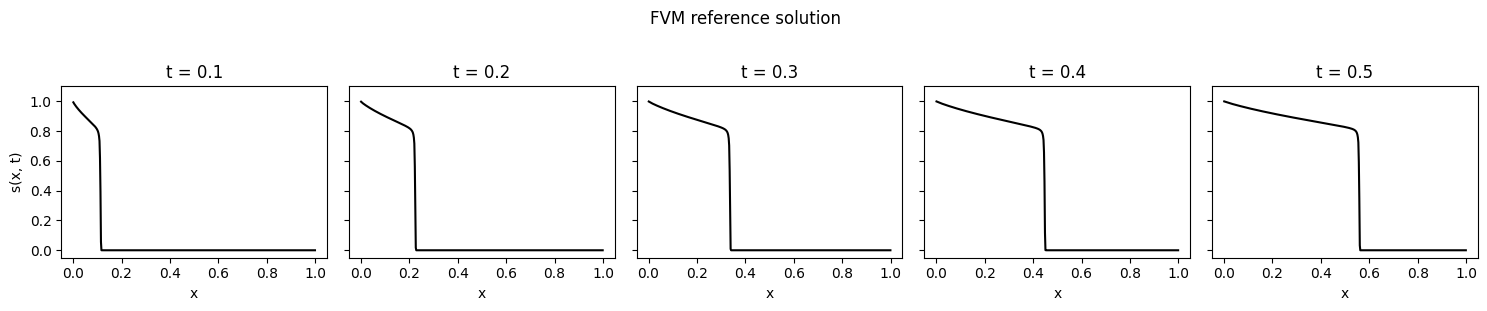

In [2]:
ref_snapshots = bl.compute_reference_solution(nx=500)
batch = bl.generate_training_data(ref_snapshots, n_pde=2000, n_bc=200, n_ic=200, n_data=200, device=device)

snap_times = sorted(t for t in ref_snapshots.keys() if t > 0)
print(f"Snapshot times: {snap_times}")
print(f"Training data: {', '.join(f'{k}: {v.shape}' for k, v in batch.items())}")

# Plot reference solution
fig, axes = plt.subplots(1, len(snap_times), figsize=(3 * len(snap_times), 3), sharey=True)
for ax, t_val in zip(axes, snap_times):
    x_ref, s_ref = ref_snapshots[t_val]
    ax.plot(x_ref, s_ref, 'k-', lw=1.5)
    ax.set_title(f't = {t_val}')
    ax.set_xlabel('x')
    ax.set_ylim(-0.05, 1.1)
axes[0].set_ylabel('s(x, t)')
fig.suptitle('FVM reference solution', y=1.02)
plt.tight_layout()
plt.show()

## 2. Load best LC-PINN checkpoint

Best model from the overnight ablation suite: v1 (lr=1e-3, 300k steps, logspace sampling, mean rel-L2 = 0.125).

In [3]:
ckpt_path = "../checkpoints/bl_lr1e3_300k_mar22.pt"
ckpt = torch.load(ckpt_path, map_location=device, weights_only=False)

model_lc = LossConditionalPINN(bl.DIM_PHYS, bl.DIM_LAMBDA, HIDDEN_DIMS).to(device)
model_lc.load_state_dict(ckpt["model_state_dict"])
model_lc.eval()

best_ll = ckpt["best_log_lambda"].to(device)
best_p = torch.softmax(best_ll, dim=0)
print(f"Loaded: {ckpt_path}")
print(f"Best λ (softmax): {best_p.cpu().numpy().round(4)}")

# Evaluate
lc_errors = bl.evaluate(model_lc, best_ll, ref_snapshots, device)
print(f"\nLC-PINN rel-L2: {lc_errors}")
print(f"Mean: {np.mean(list(lc_errors.values())):.4f}")

Loaded: ../checkpoints/bl_lr1e3_300k_mar22.pt
Best λ (softmax): [0.0008 0.6667 0.1123 0.2202]

LC-PINN rel-L2: {0.1: 0.06815367037111357, 0.2: 0.19288575191810547, 0.3: 0.1704267981433967, 0.4: 0.1597486030402313, 0.5: 0.03470932259659318}
Mean: 0.1252


## 3. Equal-weight baseline

Train a standard PINN with fixed equal weights λ = [0.25, 0.25, 0.25, 0.25] at the same step budget (300k) for fair comparison. Live loss plot updates during training.

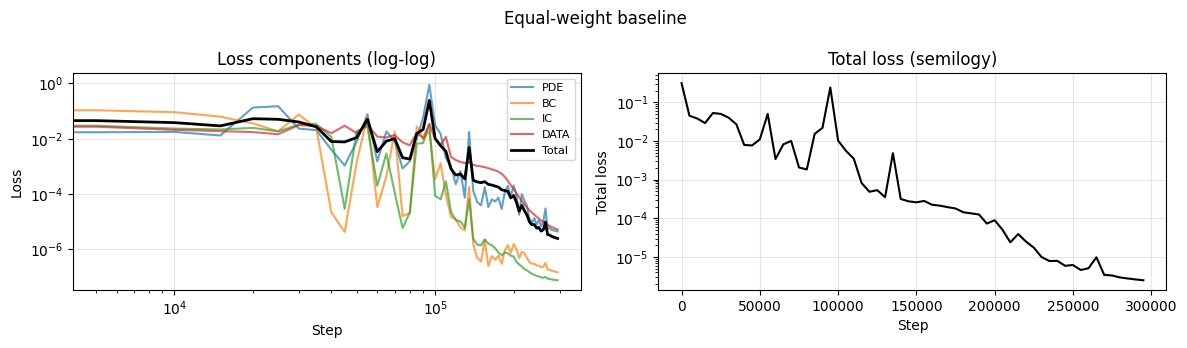

Equal-weight baseline: 100%|██████████| 300000/300000 [21:11<00:00, 235.98step/s, L=2.50e-06]

Equal-weight baseline done in 1271s (21.2 min)

Baseline rel-L2: {0.1: 0.22098562442716663, 0.2: 0.18121761040766854, 0.3: 0.2839875666242963, 0.4: 0.1202240225918156, 0.5: 0.07902150258059468}
Mean: 0.1771


In [4]:
def make_live_plot_callback(title="Training"):
    """Returns an on_log callback that updates a live loss plot in Jupyter."""
    def on_log(history):
        clear_output(wait=True)
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 3.5))
        fig.suptitle(title)
        steps = history["step"]

        ax1.set_title("Loss components (log-log)")
        for key in history:
            if key in ("step", "total", "hw", "elapsed_sec"):
                continue
            ax1.plot(steps, history[key], label=key.upper(), alpha=0.7)
        ax1.plot(steps, history["total"], 'k-', lw=2, label="Total")
        ax1.set_xscale("log")
        ax1.set_yscale("log")
        ax1.set_xlabel("Step")
        ax1.set_ylabel("Loss")
        ax1.legend(fontsize=8)
        ax1.grid(True, alpha=0.3)

        ax2.set_title("Total loss (semilogy)")
        ax2.semilogy(steps, history["total"], 'k-', lw=1.5)
        ax2.set_xlabel("Step")
        ax2.set_ylabel("Total loss")
        ax2.grid(True, alpha=0.3)

        fig.tight_layout()
        plt.show()
        plt.close(fig)

    return on_log

model_baseline = FixedWeightPINN(bl.DIM_PHYS, HIDDEN_DIMS).to(device)
baseline_history = train_fixed_pinn(
    model_baseline,
    weights=[0.25, 0.25, 0.25, 0.25],
    batch=batch,
    device=device,
    loss_fn=bl.compute_losses_fixed,
    n_epochs=N_STEPS,
    lr=LR,
    log_every=LOG_EVERY,
    desc="Equal-weight baseline",
    on_log=make_live_plot_callback("Equal-weight baseline"),
)

torch.save({"model_state_dict": model_baseline.state_dict()},
           "../checkpoints/bl_baseline_equal_300k.pt")

baseline_errors = bl.evaluate(model_baseline, None, ref_snapshots, device)
print(f"\nBaseline rel-L2: {baseline_errors}")
print(f"Mean: {np.mean(list(baseline_errors.values())):.4f}")

## 4. Bad-λ experiment — the killer figure

**Goal:** Demonstrate that LC-PINN is robust where fixed-weight PINNs break.

1. Find the **worst** λ in the LC-PINN's λ-space (maximises rel-L2 error)
2. Train a fixed-weight PINN at exactly those weights
3. Compare: the fixed-weight PINN fails; the LC-PINN at the same λ still produces a reasonable solution

This directly illustrates the value of conditioning on λ: one model covers the entire weight space, and information from good-λ regions leaks into bad-λ predictions.

In [5]:
# Step 1: Find worst λ for the trained LC-PINN
sampler = LambdaSampler(bl.DIM_LAMBDA, device=device)
bad_ll, bad_p, bad_lc_errors = find_worst_lambda(
    model_lc, ref_snapshots, sampler, device,
    predict_fn=bl.predict_solution,
    n_candidates=1000,
)
print(f"\nWorst λ (softmax): {bad_p.cpu().numpy().round(4)}")
print(f"LC-PINN at worst λ — rel-L2: {bad_lc_errors}")
print(f"LC-PINN at worst λ — mean:   {np.mean(list(bad_lc_errors.values())):.4f}")
print(f"\nLC-PINN at best  λ — mean:   {np.mean(list(lc_errors.values())):.4f}")

Worst log(lambda):     [-2.863  4.53  -0.385  2.426]
Worst weights (logspace): [5.000e-04 8.850e-01 6.500e-03 1.079e-01]
Worst mean rel-L2:     0.1256

Worst λ (softmax): [5.000e-04 8.850e-01 6.500e-03 1.079e-01]
LC-PINN at worst λ — rel-L2: {0.1: 0.06991451430924048, 0.2: 0.19289199317558006, 0.3: 0.17050991188969228, 0.4: 0.15992798621630758, 0.5: 0.03473916986720625}
LC-PINN at worst λ — mean:   0.1256

LC-PINN at best  λ — mean:   0.1252


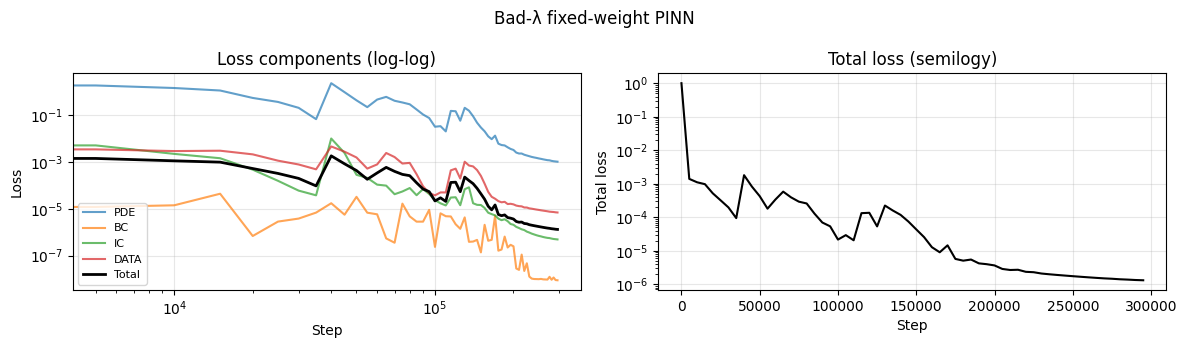

Bad-λ baseline: 100%|██████████| 300000/300000 [21:03<00:00, 237.51step/s, L=1.32e-06]

Bad-λ baseline done in 1263s (21.1 min)

Fixed-PINN @ bad λ — rel-L2: {0.1: 0.1808212097646215, 0.2: 0.16508019900912507, 0.3: 0.28601830665337724, 0.4: 0.12206020411651636, 0.5: 0.09928238535613969}
Fixed-PINN @ bad λ — mean:   0.1707


In [6]:
# Step 2: Train a fixed-weight PINN at the bad λ (with live plots)
bad_weights = bad_p.cpu().tolist()
print(f"Training fixed-weight PINN with bad λ = {[f'{w:.4f}' for w in bad_weights]}")

model_bad = FixedWeightPINN(bl.DIM_PHYS, HIDDEN_DIMS).to(device)
bad_history = train_fixed_pinn(
    model_bad,
    weights=bad_weights,
    batch=batch,
    device=device,
    loss_fn=bl.compute_losses_fixed,
    n_epochs=N_STEPS,
    lr=LR,
    log_every=LOG_EVERY,
    desc="Bad-λ baseline",
    on_log=make_live_plot_callback("Bad-λ fixed-weight PINN"),
)

torch.save({"model_state_di ct": model_bad.state_dict(), "bad_weights": bad_weights},
           "../checkpoints/bl_bad_lambda_baseline.pt")

bad_fixed_errors = bl.evaluate(model_bad, None, ref_snapshots, device)
print(f"\nFixed-PINN @ bad λ — rel-L2: {bad_fixed_errors}")
print(f"Fixed-PINN @ bad λ — mean:   {np.mean(list(bad_fixed_errors.values())):.4f}")

## 5. Comparison table & side-by-side plots

In [7]:
# --- Comparison table ---
results = {
    "LC-PINN (best λ)":       lc_errors,
    "LC-PINN (worst λ)":      bad_lc_errors,
    "Equal-weight baseline":  baseline_errors,
    "Fixed-PINN @ bad λ":     bad_fixed_errors,
}

times = sorted(snap_times)
header = f"{'Method':<26}" + "".join(f"  t={t:.1f}" for t in times) + "   Mean"
print(header)
print("-" * len(header))
for name, errs in results.items():
    vals = [errs[t] for t in times]
    row = f"{name:<26}" + "".join(f"  {v:.4f}" for v in vals) + f"  {np.mean(vals):.4f}"
    print(row)

Method                      t=0.1  t=0.2  t=0.3  t=0.4  t=0.5   Mean
--------------------------------------------------------------------
LC-PINN (best λ)            0.0682  0.1929  0.1704  0.1597  0.0347  0.1252
LC-PINN (worst λ)           0.0699  0.1929  0.1705  0.1599  0.0347  0.1256
Equal-weight baseline       0.2210  0.1812  0.2840  0.1202  0.0790  0.1771
Fixed-PINN @ bad λ          0.1808  0.1651  0.2860  0.1221  0.0993  0.1707


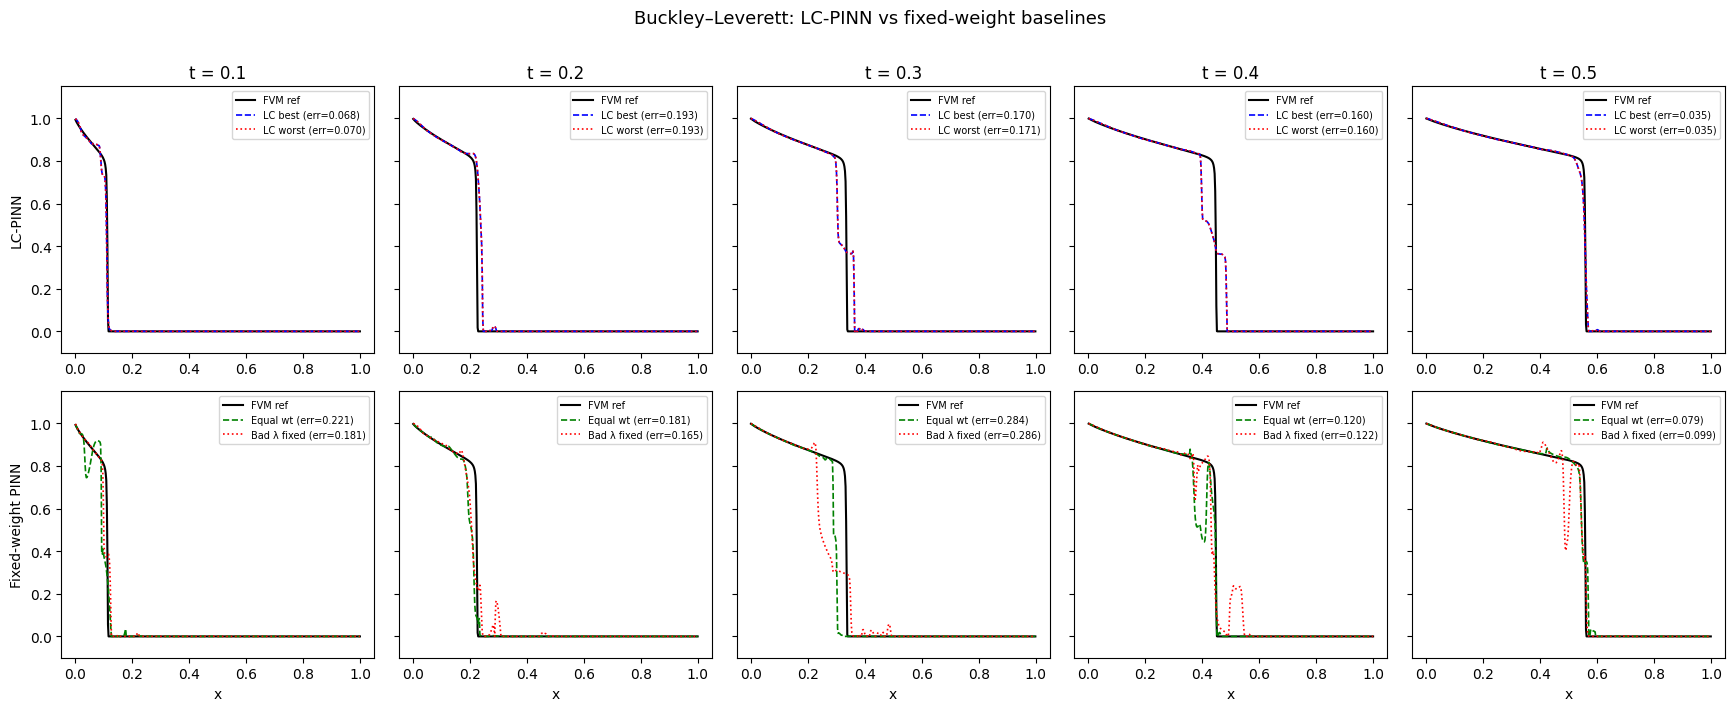

Saved: ../results/fig_bl_bad_lambda.png


In [8]:
# --- Side-by-side prediction plots ---
fig, axes = plt.subplots(2, len(times), figsize=(3.5 * len(times), 7), sharey=True)

for j, t_val in enumerate(times):
    x_ref, s_ref = ref_snapshots[t_val]

    # Top row: LC-PINN (best vs worst λ)
    ax = axes[0, j]
    s_best = bl.predict_solution(model_lc, best_ll, x_ref, t_val, device)
    s_worst = bl.predict_solution(model_lc, bad_ll, x_ref, t_val, device)
    ax.plot(x_ref, s_ref, 'k-', lw=1.5, label='FVM ref')
    ax.plot(x_ref, s_best, 'b--', lw=1.2, label=f'LC best (err={lc_errors[t_val]:.3f})')
    ax.plot(x_ref, s_worst, 'r:', lw=1.2, label=f'LC worst (err={bad_lc_errors[t_val]:.3f})')
    ax.set_title(f't = {t_val}')
    ax.legend(fontsize=7)
    ax.set_ylim(-0.1, 1.15)
    if j == 0:
        ax.set_ylabel('LC-PINN')

    # Bottom row: Fixed-weight at bad λ vs equal-weight
    ax = axes[1, j]
    s_bad_fixed = bl.predict_solution(model_bad, None, x_ref, t_val, device)
    s_equal = bl.predict_solution(model_baseline, None, x_ref, t_val, device)
    ax.plot(x_ref, s_ref, 'k-', lw=1.5, label='FVM ref')
    ax.plot(x_ref, s_equal, 'g--', lw=1.2, label=f'Equal wt (err={baseline_errors[t_val]:.3f})')
    ax.plot(x_ref, s_bad_fixed, 'r:', lw=1.2, label=f'Bad λ fixed (err={bad_fixed_errors[t_val]:.3f})')
    ax.set_xlabel('x')
    ax.legend(fontsize=7)
    ax.set_ylim(-0.1, 1.15)
    if j == 0:
        ax.set_ylabel('Fixed-weight PINN')

fig.suptitle('Buckley–Leverett: LC-PINN vs fixed-weight baselines', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('../results/fig_bl_bad_lambda.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: ../results/fig_bl_bad_lambda.png")

## 6. Uniform λ sampling ablation

Train a new LC-PINN with `mode="uniform"` and compare against the logspace LC-PINN (section 2) and equal-weight baseline (section 3).

**Runtime:** ~2.5 h at 300k steps on MPS.

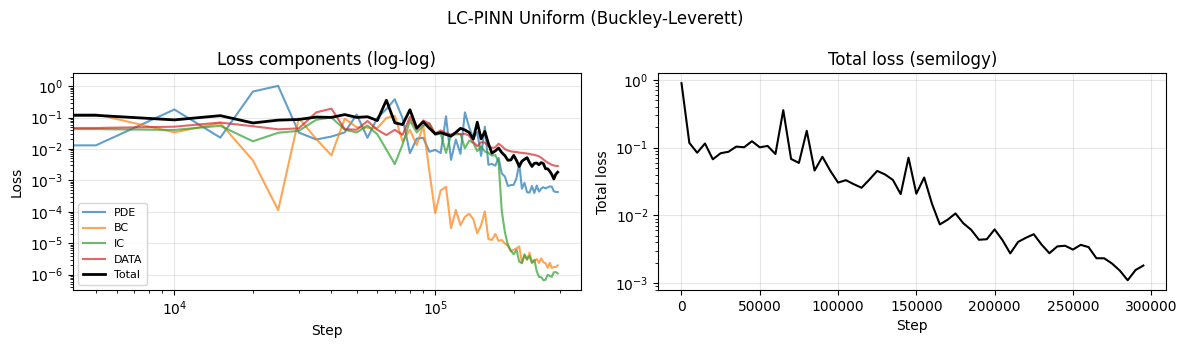

Training: 100%|██████████| 300000/300000 [1:36:06<00:00, 52.03step/s, L=1.82e-03, hw=3.00]



Training complete in 5766s (96.1 min)
Best log(lambda):     [-5.431 -2.083 -0.983 -0.128]
Best weights (uniform): [0.0044 0.1246 0.3742 0.8796]
Best validation loss: 2.805115e-03

Best lambda (uniform, raw weights): [0.0044 0.1246 0.3742 0.8796]

LC-PINN (uniform) rel-L2 per snapshot: {0.1: 0.21233609886523866, 0.2: 0.16047067912256643, 0.3: 0.1455825916334879, 0.4: 0.13805235547155284, 0.5: 0.06024871492255932}
Mean: 0.1433


In [9]:
from pinns.training import train_lc_pinn

def _bl_live_plot(title="Training"):
    def on_log(history):
        clear_output(wait=True)
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 3.5))
        fig.suptitle(title)
        steps = history["step"]
        ax1.set_title("Loss components (log-log)")
        for key in history:
            if key in ("step", "total", "hw", "elapsed_sec"): continue
            ax1.plot(steps, history[key], label=key.upper(), alpha=0.7)
        ax1.plot(steps, history["total"], 'k-', lw=2, label="Total")
        ax1.set_xscale("log"); ax1.set_yscale("log")
        ax1.set_xlabel("Step"); ax1.set_ylabel("Loss")
        ax1.legend(fontsize=8); ax1.grid(True, alpha=0.3)
        ax2.set_title("Total loss (semilogy)")
        ax2.semilogy(steps, history["total"], 'k-', lw=1.5)
        ax2.set_xlabel("Step"); ax2.set_ylabel("Total loss"); ax2.grid(True, alpha=0.3)
        fig.tight_layout(); plt.show(); plt.close(fig)
    return on_log

batch_bl = bl.generate_training_data(ref_snapshots, device=device)

model_uniform = LossConditionalPINN(bl.DIM_PHYS, bl.DIM_LAMBDA, HIDDEN_DIMS).to(device)
sampler_uniform = LambdaSampler(dim=bl.DIM_LAMBDA, device=device, mode="uniform")

history_uniform = train_lc_pinn(
    model_uniform, sampler_uniform, batch_bl, device,
    loss_fn=bl.compute_losses,
    n_epochs=N_STEPS, lr=LR, log_every=LOG_EVERY,
    on_log=_bl_live_plot("LC-PINN Uniform (Buckley-Leverett)"),
)

best_ll_uniform, best_p_uniform, _ = sweep_lambda(
    model_uniform, batch_bl, sampler_uniform, device,
    loss_fn=bl.compute_losses,
    n_candidates=500,
    exclude_terms={"pde"},
)
print(f"\nBest lambda (uniform, raw weights): {best_p_uniform.cpu().numpy().round(4)}")

torch.save({
    "model_state_dict": model_uniform.state_dict(),
    "best_log_lambda": best_ll_uniform,
}, "../checkpoints/bl_lc_pinn_uniform.pt")

uniform_errors = bl.evaluate(model_uniform, best_ll_uniform, ref_snapshots, device)
print(f"\nLC-PINN (uniform) rel-L2 per snapshot: {uniform_errors}")
print(f"Mean: {np.mean(list(uniform_errors.values())):.4f}")


## 7. Three-way comparison (baseline · logspace · uniform)

Method                          t=0.1  t=0.2  t=0.3  t=0.4  t=0.5   Mean
------------------------------------------------------------------------
Equal-weight baseline           0.2210  0.1812  0.2840  0.1202  0.0790  0.1771
LC-PINN (logspace, best λ)      0.0682  0.1929  0.1704  0.1597  0.0347  0.1252
LC-PINN (uniform, best λ)       0.2123  0.1605  0.1456  0.1381  0.0602  0.1433


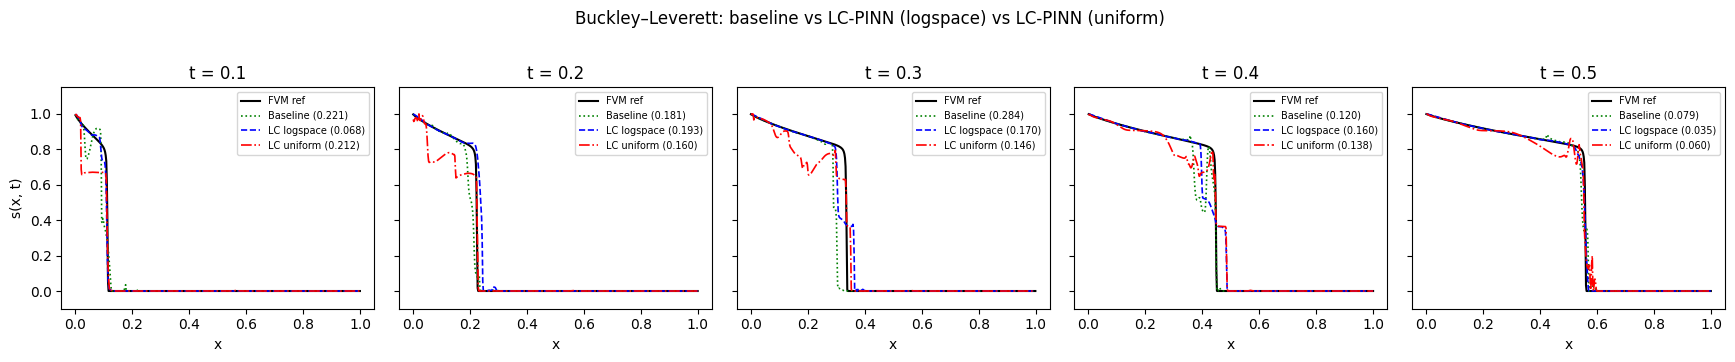

Saved: ../results/fig_bl_three_way.png


In [10]:
results = {
    "Equal-weight baseline":      baseline_errors,
    "LC-PINN (logspace, best λ)": lc_errors,
    "LC-PINN (uniform, best λ)":  uniform_errors,
}
times = sorted(snap_times)
header = f"{'Method':<30}" + "".join(f"  t={t:.1f}" for t in times) + "   Mean"
print(header)
print("-" * len(header))
for name, errs in results.items():
    vals = [errs[t] for t in times]
    row = f"{name:<30}" + "".join(f"  {v:.4f}" for v in vals) + f"  {np.mean(vals):.4f}"
    print(row)

fig, axes = plt.subplots(1, len(times), figsize=(3.5 * len(times), 3.5), sharey=True)
for ax, t_val in zip(axes, times):
    x_ref, s_ref = ref_snapshots[t_val]
    s_lc      = bl.predict_solution(model_lc,      best_ll,         x_ref, t_val, device)
    s_uniform = bl.predict_solution(model_uniform, best_ll_uniform, x_ref, t_val, device)
    s_base    = bl.predict_solution(model_baseline, None,           x_ref, t_val, device)
    ax.plot(x_ref, s_ref, 'k-', lw=1.5, label='FVM ref')
    ax.plot(x_ref, s_base,    'g:',  lw=1.2, label=f'Baseline ({baseline_errors[t_val]:.3f})')
    ax.plot(x_ref, s_lc,      'b--', lw=1.2, label=f'LC logspace ({lc_errors[t_val]:.3f})')
    ax.plot(x_ref, s_uniform, 'r-.', lw=1.2, label=f'LC uniform ({uniform_errors[t_val]:.3f})')
    ax.set_title(f't = {t_val}')
    ax.set_xlabel('x')
    ax.set_ylim(-0.1, 1.15)
    ax.legend(fontsize=7)
axes[0].set_ylabel('s(x, t)')
fig.suptitle('Buckley–Leverett: baseline vs LC-PINN (logspace) vs LC-PINN (uniform)', y=1.02)
plt.tight_layout()
plt.savefig('../results/fig_bl_three_way.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: ../results/fig_bl_three_way.png")
